# **Import libaries**

In [1]:


import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns


import warnings
warnings.filterwarnings('ignore')



train_df = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv')

test_df = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv')



print("Train Shape :", train_df.shape)
print("Test Shape  :", test_df.shape)

Train Shape : (1460, 81)
Test Shape  : (1459, 80)


# **Understand Dataset Structure & Target Variable**

In [2]:
train_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [4]:
train_df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [5]:
print(train_df['SalePrice'].head())

0    208500
1    181500
2    223500
3    140000
4    250000
Name: SalePrice, dtype: int64


# **Missing Value Analysis + Feature Type Separation**

**Check Missing Values**

In [6]:


missing_values = train_df.isnull().sum()

missing_values = missing_values[missing_values > 0]

missing_values = missing_values.sort_values(ascending=False)

print(missing_values)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


**Missing Percentage**

In [7]:


missing_percent = (train_df.isnull().sum() / len(train_df)) * 100

missing_percent = missing_percent[missing_percent > 0]

missing_percent = missing_percent.sort_values(ascending=False)

print(missing_percent)

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
BsmtExposure     2.602740
BsmtFinType2     2.602740
BsmtQual         2.534247
BsmtCond         2.534247
BsmtFinType1     2.534247
MasVnrArea       0.547945
Electrical       0.068493
dtype: float64


**Separate Numerical & Categorical Features**

In [8]:


num_cols = train_df.select_dtypes(
    include=['int64', 'float64']
).columns

print("Number of Numerical Features :", len(num_cols))

print(num_cols)

Number of Numerical Features : 38
Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')


In [9]:


cat_cols = train_df.select_dtypes(
    include=['object']
).columns

print("Number of Categorical Features :", len(cat_cols))

print(cat_cols)

Number of Categorical Features : 43
Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')


**Dataset Balance**

In [10]:
print("Train Shape :", train_df.shape)
print("Test Shape :", test_df.shape)

print("\nTarget Column:")
print(train_df['SalePrice'].describe())

Train Shape : (1460, 81)
Test Shape : (1459, 80)

Target Column:
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


# **Visualize Target Variable (SalePrice) and Understand Skewness**

**Plot SalePrice Distribution**

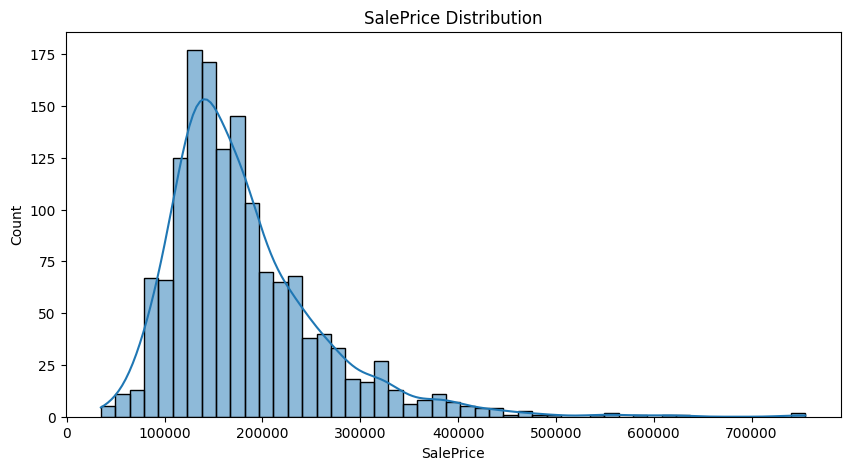

In [11]:
plt.figure(figsize=(10,5))

sns.histplot(train_df['SalePrice'], kde=True)

plt.title("SalePrice Distribution")

plt.show()

**Check Skewness Numerically**

In [12]:
print("Skewness :", train_df['SalePrice'].skew())

Skewness : 1.8828757597682129


**Apply Log Transformation**

In [13]:
train_df['SalePrice_Log'] = np.log1p(train_df['SalePrice'])

**Plot Log-Transformed Distribution**

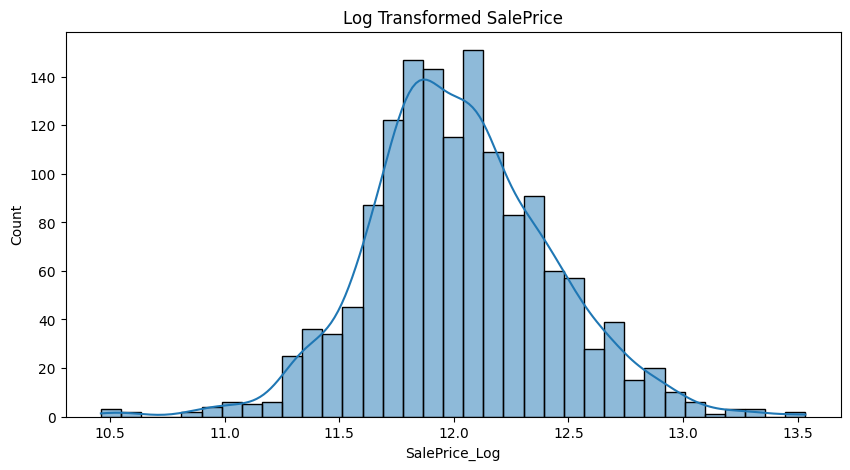

In [14]:
plt.figure(figsize=(10,5))

sns.histplot(train_df['SalePrice_Log'], kde=True)

plt.title("Log Transformed SalePrice")

plt.show()

**Check New Skewness**

In [15]:
print("New Skewness :", train_df['SalePrice_Log'].skew())

New Skewness : 0.12134661989685333


In [16]:
train_df=train_df.drop(columns=["SalePrice"])

# **Correlation Analysis & Finding Important**

**Correlation Matrix**

In [17]:
correlation_matrix = train_df.corr(numeric_only=True)

correlation_matrix.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice_Log
Id,1.000000,0.011156,-0.010601,-0.033226,-0.028365,0.012609,-0.012713,-0.021998,-0.050298,-0.005024,...,-0.029643,-0.000477,0.002889,-0.046635,0.001330,0.057044,-0.006242,0.021172,0.000712,-0.017942
MSSubClass,0.011156,1.000000,-0.386347,-0.139781,0.032628,-0.059316,0.027850,0.040581,0.022936,-0.069836,...,-0.012579,-0.006100,-0.012037,-0.043825,-0.026030,0.008283,-0.007683,-0.013585,-0.021407,-0.073959
LotFrontage,-0.010601,-0.386347,1.000000,0.426095,0.251646,-0.059213,0.123349,0.088866,0.193458,0.233633,...,0.088521,0.151972,0.010700,0.070029,0.041383,0.206167,0.003368,0.011200,0.007450,0.355879
LotArea,-0.033226,-0.139781,0.426095,1.000000,0.105806,-0.005636,0.014228,0.013788,0.104160,0.214103,...,0.171698,0.084774,-0.018340,0.020423,0.043160,0.077672,0.038068,0.001205,-0.014261,0.257320
OverallQual,-0.028365,0.032628,0.251646,0.105806,1.000000,-0.091932,0.572323,0.550684,0.411876,0.239666,...,0.238923,0.308819,-0.113937,0.030371,0.064886,0.065166,-0.031406,0.070815,-0.027347,0.817185


**Find Correlation With Target**

In [18]:
saleprice_corr = correlation_matrix['SalePrice_Log']

saleprice_corr = saleprice_corr.sort_values(ascending=False)

print(saleprice_corr)

SalePrice_Log    1.000000
OverallQual      0.817185
GrLivArea        0.700927
GarageCars       0.680625
GarageArea       0.650888
TotalBsmtSF      0.612134
1stFlrSF         0.596981
FullBath         0.594771
YearBuilt        0.586570
YearRemodAdd     0.565608
GarageYrBlt      0.541073
TotRmsAbvGrd     0.534422
Fireplaces       0.489450
MasVnrArea       0.430809
BsmtFinSF1       0.372023
LotFrontage      0.355879
WoodDeckSF       0.334135
OpenPorchSF      0.321053
2ndFlrSF         0.319300
HalfBath         0.313982
LotArea          0.257320
BsmtFullBath     0.236224
BsmtUnfSF        0.221985
BedroomAbvGr     0.209043
ScreenPorch      0.121208
PoolArea         0.069798
MoSold           0.057330
3SsnPorch        0.054900
BsmtFinSF2       0.004832
BsmtHalfBath    -0.005149
Id              -0.017942
MiscVal         -0.020021
OverallCond     -0.036868
YrSold          -0.037263
LowQualFinSF    -0.037963
MSSubClass      -0.073959
KitchenAbvGr    -0.147548
EnclosedPorch   -0.149050
Name: SalePr

**Visualize Top Correlated Features**

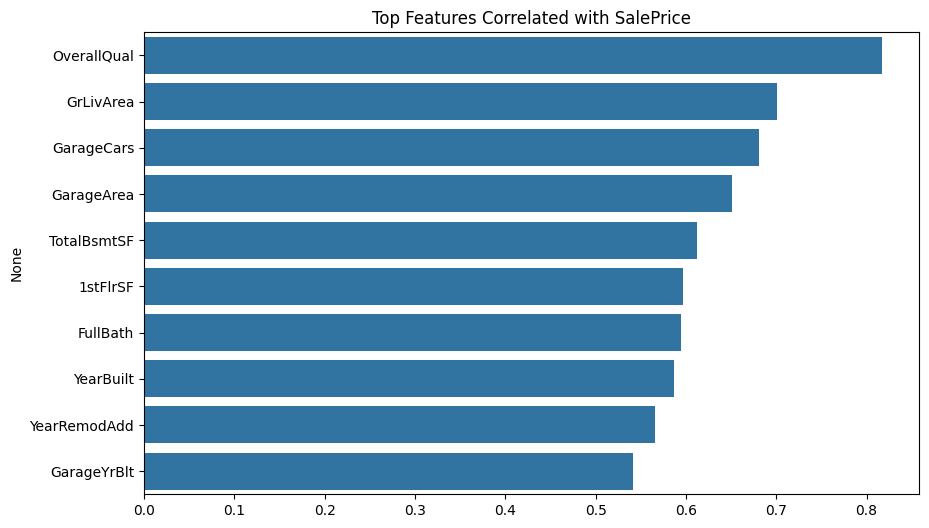

In [19]:
top_corr = saleprice_corr[1:11]

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_corr.values,
    y=top_corr.index
)

plt.title("Top Features Correlated with SalePrice")

plt.show()

**Heatmap of Top Features**

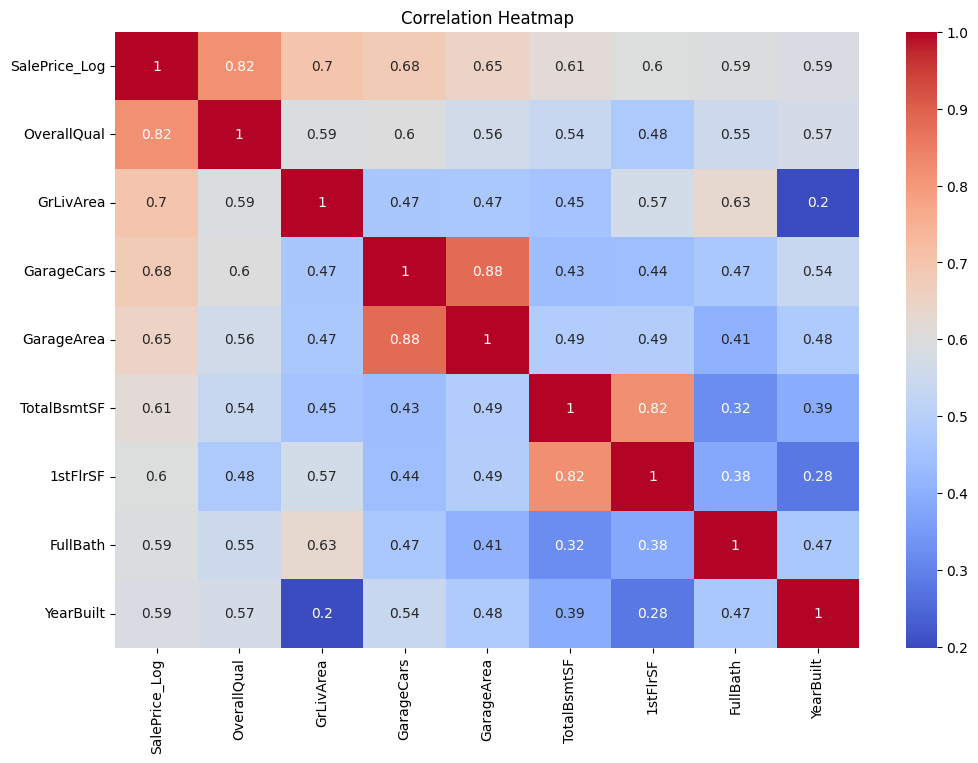

In [20]:
important_features = [
    'SalePrice_Log',
    'OverallQual',
    'GrLivArea',
    'GarageCars',
    'GarageArea',
    'TotalBsmtSF',
    '1stFlrSF',
    'FullBath',
    'YearBuilt'
]

plt.figure(figsize=(12,8))

sns.heatmap(
    train_df[important_features].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

**Scatter Plot of Important Features**

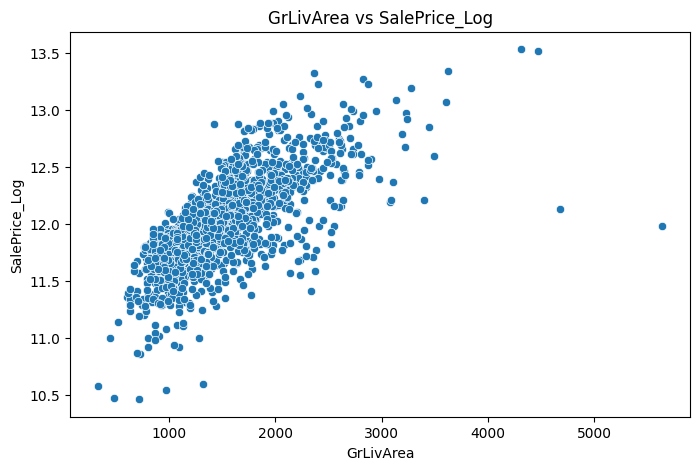

In [21]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=train_df['GrLivArea'],
    y=train_df['SalePrice_Log']
)

plt.title("GrLivArea vs SalePrice_Log")

plt.show()

# **Outlier Detection & Removal**

**Visualize Outliers**

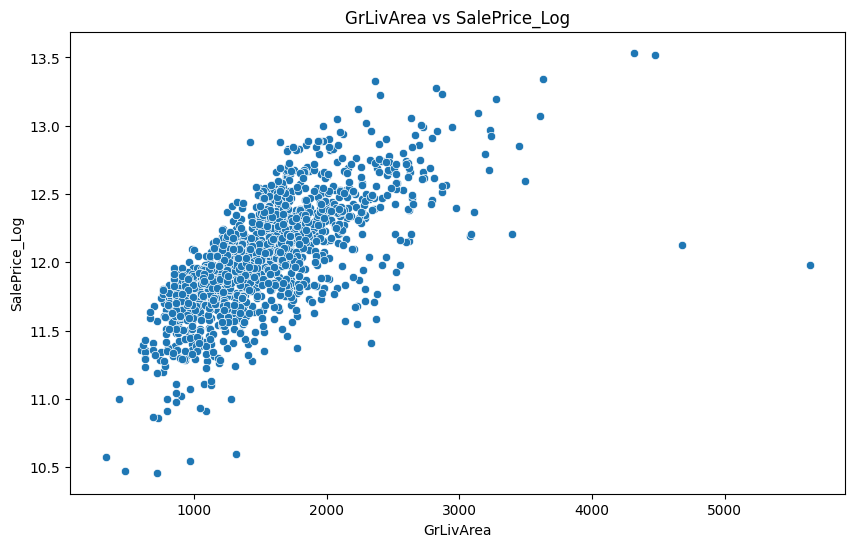

In [22]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=train_df['GrLivArea'],
    y=train_df['SalePrice_Log']
)

plt.title("GrLivArea vs SalePrice_Log")

plt.show()

**Identify Extreme Outliers**

In [23]:
train_df[
    (train_df['GrLivArea'] > 4000) &
    (train_df['SalePrice_Log'] < 300000)
]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice_Log
523,524,60,RL,130.0,40094,Pave,NaN,IR1,Bnk,AllPub,...,0,NaN,NaN,NaN,0,10,2007,New,Partial,12.126764
691,692,60,RL,104.0,21535,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2007,WD,Normal,13.534474
1182,1183,60,RL,160.0,15623,Pave,NaN,IR1,Lvl,AllPub,...,555,Ex,MnPrv,NaN,0,7,2007,WD,Abnorml,13.521141
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,11.982935


**Remove Outliers**

In [24]:
train_df = train_df.drop(
    train_df[
        (train_df['GrLivArea'] > 4000) &
        (train_df['SalePrice_Log'] < 300000)
    ].index
)

print("New Shape :", train_df.shape)

New Shape : (1456, 81)


**Recheck Scatter Plot**

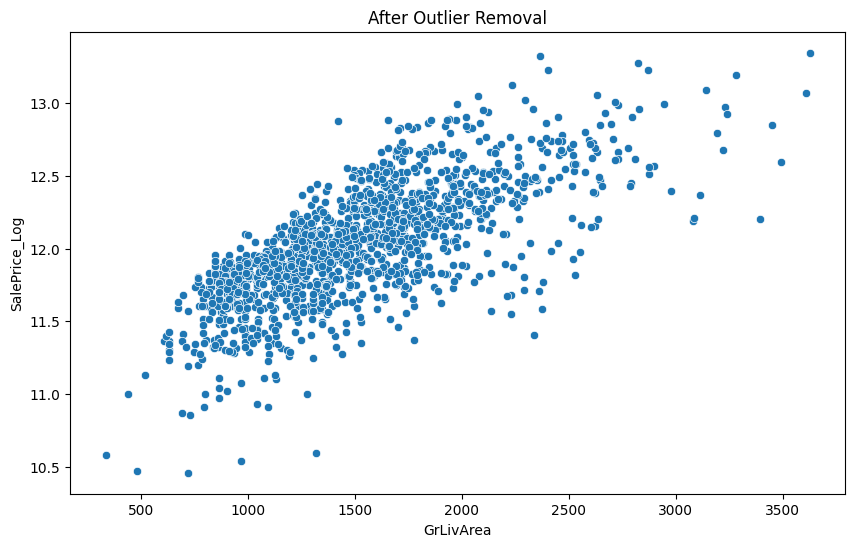

In [25]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=train_df['GrLivArea'],
    y=train_df['SalePrice_Log']
)

plt.title("After Outlier Removal")

plt.show()

# **Combine Train & Test Data for Unified Preprocessing**

**Separate Features & Target**

In [26]:
X = train_df.drop([ 'SalePrice_Log'], axis=1)

y = train_df['SalePrice_Log']

**Check Shapes**

In [27]:
print("X Shape :", X.shape)
print("y Shape :", y.shape)
print("Test Shape :", test_df.shape)

X Shape : (1456, 80)
y Shape : (1456,)
Test Shape : (1459, 80)


**Combine Train & Test Features**

In [28]:
all_data = pd.concat([X, test_df], axis=0)

print("Combined Shape :", all_data.shape)

Combined Shape : (2915, 80)


**Check Missing Values Again**

In [29]:
missing = all_data.isnull().sum()

missing = missing[missing > 0]

missing = missing.sort_values(ascending=False)

print(missing.head(20))

PoolQC          2907
MiscFeature     2810
Alley           2717
Fence           2345
MasVnrType      1765
FireplaceQu     1420
LotFrontage      486
GarageQual       159
GarageYrBlt      159
GarageCond       159
GarageFinish     159
GarageType       157
BsmtExposure      82
BsmtCond          82
BsmtQual          81
BsmtFinType2      80
BsmtFinType1      79
MasVnrArea        23
MSZoning           4
BsmtFullBath       2
dtype: int64


# **Missing Value Handling**

**Columns Where NA Means “None”**

In [30]:


none_cols = [
    'PoolQC',
    'MiscFeature',
    'Alley',
    'Fence',
    'FireplaceQu',
    'GarageType',
    'GarageFinish',
    'GarageQual',
    'GarageCond',
    'BsmtQual',
    'BsmtCond',
    'BsmtExposure',
    'BsmtFinType1',
    'BsmtFinType2',
    'MasVnrType'
]

for col in none_cols:
    all_data[col] = all_data[col].fillna('None')

# **Numerical Features Where NA Means 0**

In [31]:


zero_cols = [
    'GarageYrBlt',
    'GarageArea',
    'GarageCars',
    'BsmtFinSF1',
    'BsmtFinSF2',
    'BsmtUnfSF',
    'TotalBsmtSF',
    'BsmtFullBath',
    'BsmtHalfBath',
    'MasVnrArea'
]

for col in zero_cols:
    all_data[col] = all_data[col].fillna(0)

**Handle LotFrontage**

In [32]:
all_data['LotFrontage'] = all_data.groupby(
    'Neighborhood'
)['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)

**Fill Remaining Categorical Missing Values**

In [33]:
for col in all_data.select_dtypes(include='object'):
    all_data[col] = all_data[col].fillna(
        all_data[col].mode()[0]
    )

**Fill Remaining Numerical Missing Values**

In [34]:
for col in all_data.select_dtypes(include=['int64', 'float64']):
    all_data[col] = all_data[col].fillna(
        all_data[col].median()
    )

**Verify Missing Values**

In [35]:
print(all_data.isnull().sum().sum())

0


# **Feature Engineering**

**Total Square Footage**

In [36]:
all_data['TotalSF'] = (
    all_data['TotalBsmtSF'] +
    all_data['1stFlrSF'] +
    all_data['2ndFlrSF']
)

**Total Bathrooms**

In [37]:
all_data['TotalBath'] = (
    all_data['FullBath'] +
    (0.5 * all_data['HalfBath']) +
    all_data['BsmtFullBath'] +
    (0.5 * all_data['BsmtHalfBath'])
)

**House Age**

In [38]:
all_data['HouseAge'] = (
    all_data['YrSold'] -
    all_data['YearBuilt']
)

**Remodel Age**

In [39]:
all_data['RemodelAge'] = (
    all_data['YrSold'] -
    all_data['YearRemodAdd']
)

**Total Porch Area**

In [40]:
all_data['TotalPorchSF'] = (
    all_data['OpenPorchSF'] +
    all_data['EnclosedPorch'] +
    all_data['3SsnPorch'] +
    all_data['ScreenPorch']
)

**Has Garage Feature**

In [41]:
all_data['HasGarage'] = (
    all_data['GarageArea'] > 0
).astype(int)

**Has Basement Feature**

In [42]:
all_data['HasBsmt'] = (
    all_data['TotalBsmtSF'] > 0
).astype(int)

**Has Fireplace Feature**

In [43]:
all_data['HasFireplace'] = (
    all_data['Fireplaces'] > 0
).astype(int)

**New Shape**

In [44]:
print(all_data.shape)

(2915, 88)


In [45]:
all_data

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,SaleType,SaleCondition,TotalSF,TotalBath,HouseAge,RemodelAge,TotalPorchSF,HasGarage,HasBsmt,HasFireplace
0,1,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,...,WD,Normal,2566.0,3.5,5,5,61,1,1,0
1,2,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,...,WD,Normal,2524.0,2.5,31,31,0,1,1,1
2,3,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,...,WD,Normal,2706.0,3.5,7,6,42,1,1,1
3,4,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,...,WD,Abnorml,2473.0,2.0,91,36,307,1,1,1
4,5,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,...,WD,Normal,3343.0,3.5,8,8,84,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,2915,160,RM,21.0,1936,Pave,None,Reg,Lvl,AllPub,...,WD,Normal,1638.0,1.5,36,36,0,0,1,0
1455,2916,160,RM,21.0,1894,Pave,None,Reg,Lvl,AllPub,...,WD,Abnorml,1638.0,1.5,36,36,24,1,1,0
1456,2917,20,RL,160.0,20000,Pave,None,Reg,Lvl,AllPub,...,WD,Abnorml,2448.0,2.0,46,10,0,1,1,1
1457,2918,85,RL,62.0,10441,Pave,None,Reg,Lvl,AllPub,...,WD,Normal,1882.0,1.5,14,14,32,0,1,0


# **Encode Categorical Features**

**Current Shape**

In [46]:
print("Before Encoding :", all_data.shape)

Before Encoding : (2915, 88)


**Apply One-Hot Encoding**

In [47]:
all_data = pd.get_dummies(all_data)

print("After Encoding :", all_data.shape)

After Encoding : (2915, 310)


**Verify No Object Columns Remain**

In [48]:
remaining_obj = all_data.select_dtypes(include='object').columns

print(remaining_obj)

Index([], dtype='object')


# **Split Combined Data Back Into Train & Test Sets**

**Original Train Size**

In [49]:
print(X.shape)

(1456, 80)


**Split Back**

In [50]:
X_processed = all_data[:len(X)]

test_processed = all_data[len(X):]

**Check Shapes**

In [51]:
print("Processed Train Shape :", X_processed.shape)

print("Processed Test Shape :", test_processed.shape)

print("Target Shape :", y.shape)

Processed Train Shape : (1456, 310)
Processed Test Shape : (1459, 310)
Target Shape : (1456,)


**Matching Rows**

In [52]:
print(X_processed.shape[0] == y.shape[0])

True


# **Train/Validation Split + First Baseline Model**

**Train/Validation Split**

In [53]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X_processed,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train :", X_train.shape)
print("X_valid :", X_valid.shape)

X_train : (1164, 310)
X_valid : (292, 310)


**Train Linear Regression Model**

In [54]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

LinearRegression()

**Make Predictions**

In [55]:
y_pred = lr_model.predict(X_valid)

# **Evaluate Model**

**RMSE (Root Mean Squared Error)**

In [56]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_valid, y_pred))

print("RMSE :", rmse)

RMSE : 0.1301737424715653


**Check Training Score**

In [57]:
print("Train Score :", lr_model.score(X_train, y_train))

print("Validation Score :", lr_model.score(X_valid, y_valid))

Train Score : 0.9529685044957457
Validation Score : 0.8927100986335585


# **Random Forest & XGBoost (Powerful Ensemble Models)**

**Random Forest**

In [58]:
from sklearn.model_selection import cross_val_score


In [59]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_valid)

**Random Forest RMSE**

In [60]:
rf_rmse = np.sqrt(
    mean_squared_error(y_valid, rf_pred)
)

print("Random Forest RMSE :", rf_rmse)

Random Forest RMSE : 0.14337909454284262


**Random Forest Cross Validation**

In [61]:
rf_cv = np.sqrt(
    -cross_val_score(
        rf_model,
        X_processed,
        y,
        scoring='neg_mean_squared_error',
        cv=5
    )
)

print("Random Forest CV RMSE :", rf_cv.mean())

Random Forest CV RMSE : 0.1368213972287458


**XGBoost**

In [62]:
import xgboost

from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train
)

xgb_pred = xgb_model.predict(X_valid)

**XGBoost RMSE**

In [63]:
xgb_rmse = np.sqrt(
    mean_squared_error(y_valid, xgb_pred)
)

print("XGBoost RMSE :", xgb_rmse)

XGBoost RMSE : 0.12136029667869441


**XGBoost Cross Validation**

In [64]:
xgb_cv = np.sqrt(
    -cross_val_score(
        xgb_model,
        X_processed,
        y,
        scoring='neg_mean_squared_error',
        cv=5
    )
)

print("XGBoost CV RMSE :", xgb_cv.mean())

XGBoost CV RMSE : 0.11610353326652127


# **Feature Importance Visualization & Model Interpretation**

**Random Forest Feature Importance**

In [65]:
feature_importance = pd.DataFrame({
    'Feature': X_processed.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
37,TotalSF,0.416927
4,OverallQual,0.344615
27,GarageArea,0.014081
16,GrLivArea,0.013741
26,GarageCars,0.011640
38,TotalBath,0.011511
9,BsmtFinSF1,0.011382
39,HouseAge,0.008972
5,OverallCond,0.008656
3,LotArea,0.008249


**Visualize Top 15 Features**

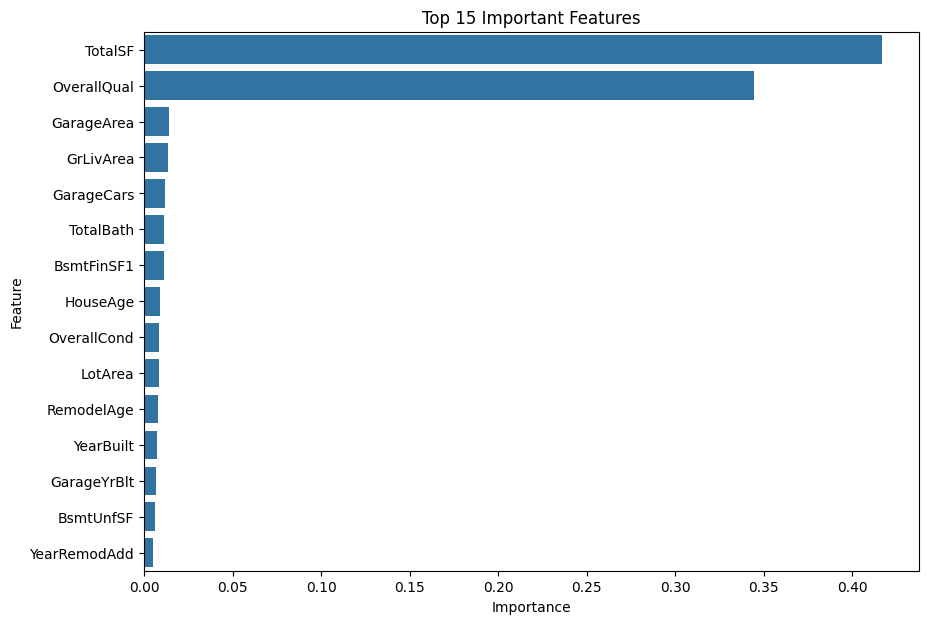

In [66]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10,7))

sns.barplot(
    x=top_features['Importance'],
    y=top_features['Feature']
)

plt.title("Top 15 Important Features")

plt.show()

**XGBoost Feature Importance**

In [67]:
xgb_importance = pd.DataFrame({
    'Feature': X_processed.columns,
    'Importance': xgb_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    by='Importance',
    ascending=False
)

xgb_importance.head(15)

,Feature,Importance
4,OverallQual,0.115544
179,ExterQual_TA,0.105595
37,TotalSF,0.101778
191,BsmtQual_Ex,0.036391
26,GarageCars,0.035927
232,CentralAir_Y,0.033912
38,TotalBath,0.031593
240,KitchenQual_Gd,0.026649
231,CentralAir_N,0.025915
241,KitchenQual_TA,0.024321


**Visualize XGBoost Importance**

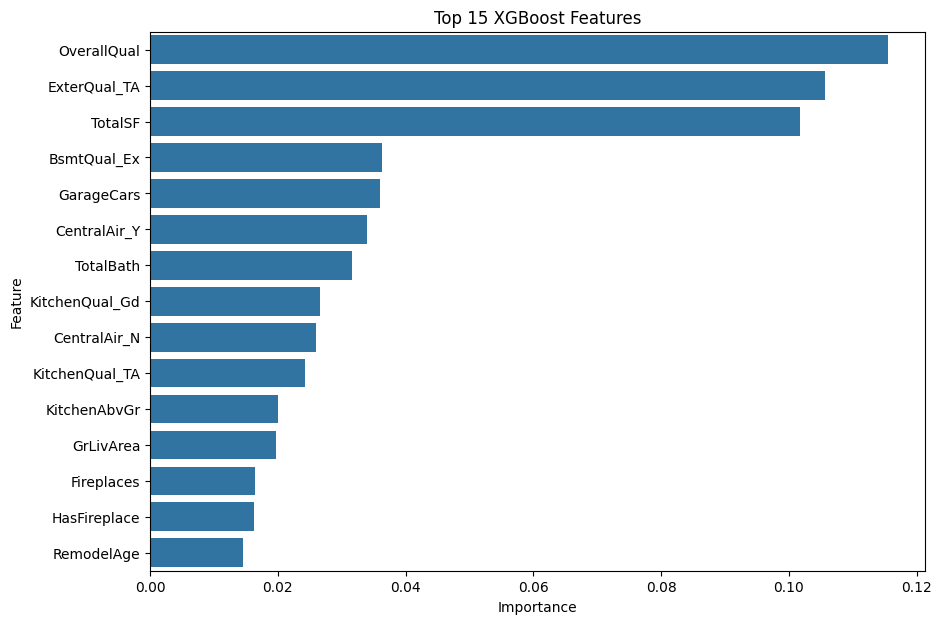

In [68]:
top_xgb = xgb_importance.head(15)

plt.figure(figsize=(10,7))

sns.barplot(
    x=top_xgb['Importance'],
    y=top_xgb['Feature']
)

plt.title("Top 15 XGBoost Features")

plt.show()

**Compare Predictions vs Actual Values**

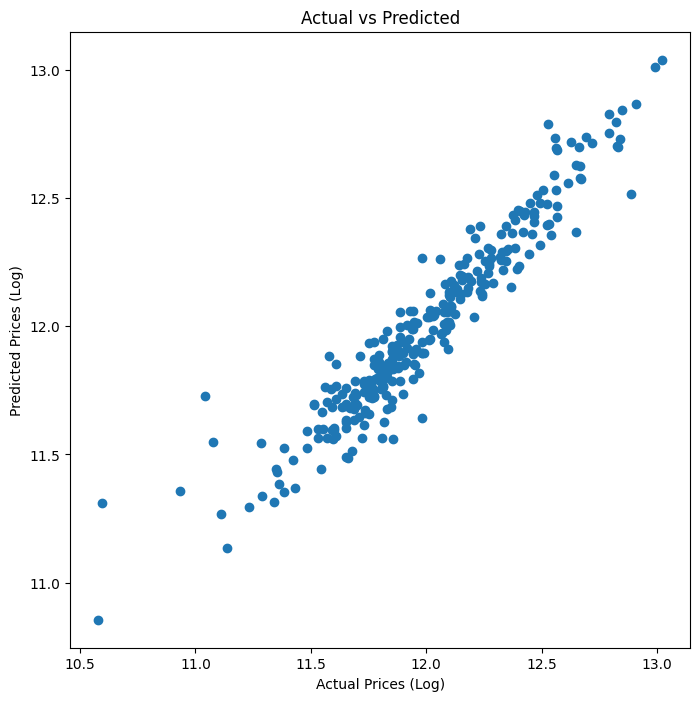

In [69]:
plt.figure(figsize=(8,8))

plt.scatter(y_valid, xgb_pred)

plt.xlabel("Actual Prices (Log)")
plt.ylabel("Predicted Prices (Log)")

plt.title("Actual vs Predicted")

plt.show()

# **Final Model Training & Kaggle Submission File Creation**

**Train Final Model on Full Data**

In [70]:
final_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

final_model.fit(X_processed, y)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

**Predict Test Dataset**

In [71]:
test_predictions_log = final_model.predict(test_processed)

**Reverse Log Transformation**

In [72]:
test_predictions = np.expm1(test_predictions_log)

**Create Submission File**

In [73]:
submission = pd.DataFrame({
    'Id': test_df['Id'],
    'SalePrice': test_predictions
})

submission.head()

,Id,SalePrice
0,1461,123489.546875
1,1462,159129.656250
2,1463,180818.250000
3,1464,190193.906250
4,1465,184650.656250


**Save CSV File**

In [74]:
submission.to_csv(
    'submission.csv',
    index=False
)

print("submission.csv created successfully!")

submission.csv created successfully!


# **Save Model Code**

In [75]:
import pickle



pickle.dump(final_model, open('model.pkl', 'wb'))



pickle.dump(X_processed.columns, open('columns.pkl', 'wb'))

print("Model and columns saved successfully!")

Model and columns saved successfully!
